# Q1.1 Advanced Carbon Price Modeling

This notebook documents the advanced techniques used to overcome the limitations of the previous Recursive LightGBM model. We implement **Direct Forecasting**, **Vectorized Feature Engineering**, and an **Ensemble** approach to reduce variance and prevent error compounding.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
import joblib
import math
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

### 1. Vectorized Feature Engineering
Instead of generating features iteratively during the prediction loop, we calculate lags and rolling statistics for the entire dataset upfront. This is much faster and enables Direct Forecasting.

In [2]:
TEST_HORIZON = 30
FEATURES = ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
            'roll_mean_7d', 'roll_mean_30d', 'roll_std_30d',
            'dayofweek', 'month', 'day_sin', 'day_cos']
CATEGORICAL = ['market_encoded']

def add_features_vectorized(df):
    df = df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day_sin'] = np.sin(2 * np.pi * df['date'].dt.day / 31.0)
    df['day_cos'] = np.cos(2 * np.pi * df['date'].dt.day / 31.0)
    
    res = []
    for market, grp in df.groupby('market'):
        grp = grp.sort_values('date')
        for lag in [1, 2, 3, 7, 14, 30]:
            grp[f'lag_{lag}'] = grp['price'].shift(lag)
        
        grp['roll_mean_7d'] = grp['price'].rolling(window=7, min_periods=1).mean()
        grp['roll_mean_30d'] = grp['price'].rolling(window=30, min_periods=1).mean()
        grp['roll_std_30d'] = grp['price'].rolling(window=30, min_periods=1).std().fillna(0.0)
        
        for lag in [1, 2, 3, 7, 14, 30]:
            grp[f'lag_{lag}'] = grp[f'lag_{lag}'].bfill()
        res.append(grp)
        
    return pd.concat(res).reset_index(drop=True)


### 2. Loading Data

In [3]:
df = pd.read_csv('../../data/processed/prices_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = add_features_vectorized(df)

train_list, test_list = [], []
for market, grp in df.groupby('market'):
    grp = grp.sort_values('date')
    train_list.append(grp.iloc[:-TEST_HORIZON])
    test_list.append(grp.iloc[-TEST_HORIZON:])
    
df_train = pd.concat(train_list).reset_index(drop=True)
df_test = pd.concat(test_list).reset_index(drop=True)

### 3. Direct LightGBM Forecasting
Instead of one model predicting recursively, we train 30 separate models. Model `h` targets the price exactly `h` days in the future (`price.shift(-h)`). This prevents error propagation during market shocks.

In [4]:
market_mapping = {m: i for i, m in enumerate(df_train['market'].unique())}
df_train['market_encoded'] = df_train['market'].map(market_mapping)

models = {}
for h in range(1, TEST_HORIZON + 1):
    df_train_h = df_train.copy()
    df_train_h['target'] = df_train_h.groupby('market')['price'].shift(-h)
    df_train_h = df_train_h.dropna(subset=['target'] + FEATURES)
    
    X_train = df_train_h[FEATURES + CATEGORICAL]
    y_train = df_train_h['target']
    
    lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
    lgb_model.fit(X_train, y_train, categorical_feature=['market_encoded'])
    models[h] = lgb_model

print("Successfully trained 30 Direct Forecasting LightGBM models.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2372
[LightGBM] [Info] Number of data points in the train set: 15711, number of used features: 14
[LightGBM] [Info] Start training from score 26.829976
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000384 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2372
[LightGBM] [Info] Number of data points in the train s

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

### 4. Saving the Separate Advanced Model
As requested, we save this advanced pipeline separately as `carbon_price_advanced_lgbm.pkl` instead of overwriting the previous iteration.

In [5]:
os.makedirs('../../models', exist_ok=True)
joblib.dump({
    'models': models, 
    'features': FEATURES, 
    'categorical': CATEGORICAL, 
    'market_mapping': market_mapping
}, '../../models/carbon_price_advanced_lgbm.pkl')
print("Saved advanced model to models/carbon_price_advanced_lgbm.pkl")

Saved advanced model to models/carbon_price_advanced_lgbm.pkl


In [6]:
# Generate predictions for Direct LightGBM and Ensemble
last_train_rows = df_train.groupby('market').last().reset_index()

direct_lgbm_forecasts = []
naive_forecasts = []

for market in last_train_rows['market']:
    last_price = last_train_rows[last_train_rows['market'] == market]['price'].values[0]
    test_market = df_test[df_test['market'] == market].sort_values('date')
    
    for h in range(1, TEST_HORIZON + 1):
        test_row = test_market.iloc[h-1]
        
        # Predict Direct LightGBM
        X = last_train_rows[last_train_rows['market'] == market][FEATURES + CATEGORICAL]
        pred = models[h].predict(X)[0]
        
        direct_lgbm_forecasts.append({
            'market': market,
            'currency': test_row['currency'],
            'date': test_row['date'],
            'actual_price': test_row['price'],
            'predicted_price': pred,
            'model_name': 'Direct LightGBM'
        })
        
        naive_forecasts.append({
            'market': market,
            'currency': test_row['currency'],
            'date': test_row['date'],
            'actual_price': test_row['price'],
            'predicted_price': last_price,
            'model_name': 'Naive Persistence'
        })

direct_df = pd.DataFrame(direct_lgbm_forecasts)
naive_df = pd.DataFrame(naive_forecasts)

ensemble_df = direct_df.copy()
ensemble_df['predicted_price'] = (direct_df['predicted_price'] + naive_df['predicted_price']) / 2
ensemble_df['model_name'] = 'Ensemble (LGBM+Naive)'

# Load existing forecasts to append
forecasts = pd.read_csv('../../data/outputs/q1_price_forecasts.csv')
forecasts['date'] = pd.to_datetime(forecasts['date'])

# Remove old Naive Persistence if present, so we don't duplicate
forecasts = forecasts[~forecasts['model_name'].isin(['Naive Persistence', 'Direct LightGBM', 'Ensemble (LGBM+Naive)'])]

# Append our new forecasts
forecasts = pd.concat([forecasts, naive_df, direct_df, ensemble_df], ignore_index=True)

# Save back to CSV
forecasts.to_csv('../../data/outputs/q1_price_forecasts.csv', index=False)
print("Saved Direct LightGBM and Ensemble predictions to q1_price_forecasts.csv")

Saved Direct LightGBM and Ensemble predictions to q1_price_forecasts.csv


### 5. Evaluation and Comparison
We compare the Baseline (Naive Persistence) MAPE against our final Advanced model (Direct LGBM + Naive Ensemble) across all markets. The predictions are loaded directly from the pipeline output.

In [7]:
forecasts = pd.read_csv('../../data/outputs/q1_price_forecasts.csv')
forecasts['date'] = pd.to_datetime(forecasts['date'])

def calculate_mape(df, model_name):
    sub = df[df['model_name'] == model_name]
    return mean_absolute_percentage_error(sub['actual_price'], sub['predicted_price'])

baseline_mape = calculate_mape(forecasts, 'Naive Persistence')
final_mape = calculate_mape(forecasts, 'Ensemble (LGBM+Naive)')
direct_mape = calculate_mape(forecasts, 'Direct LightGBM')

print(f"Baseline (Naive Persistence) MAPE: {baseline_mape:.4f} ({baseline_mape*100:.2f}%)")
print(f"Direct LightGBM MAPE:            {direct_mape:.4f} ({direct_mape*100:.2f}%)")
print(f"Final Model (Ensemble) MAPE:     {final_mape:.4f} ({final_mape*100:.2f}%)")

Baseline (Naive Persistence) MAPE: 0.0293 (2.93%)
Direct LightGBM MAPE:            0.0249 (2.49%)
Final Model (Ensemble) MAPE:     0.0245 (2.45%)


### 6. Visualizations
Visualizing the 30-day forecast trajectories for each market. Notice how the Ensemble model smooths out the variance of the Direct LightGBM model, anchoring it closer to the persistence baseline during high volatility.

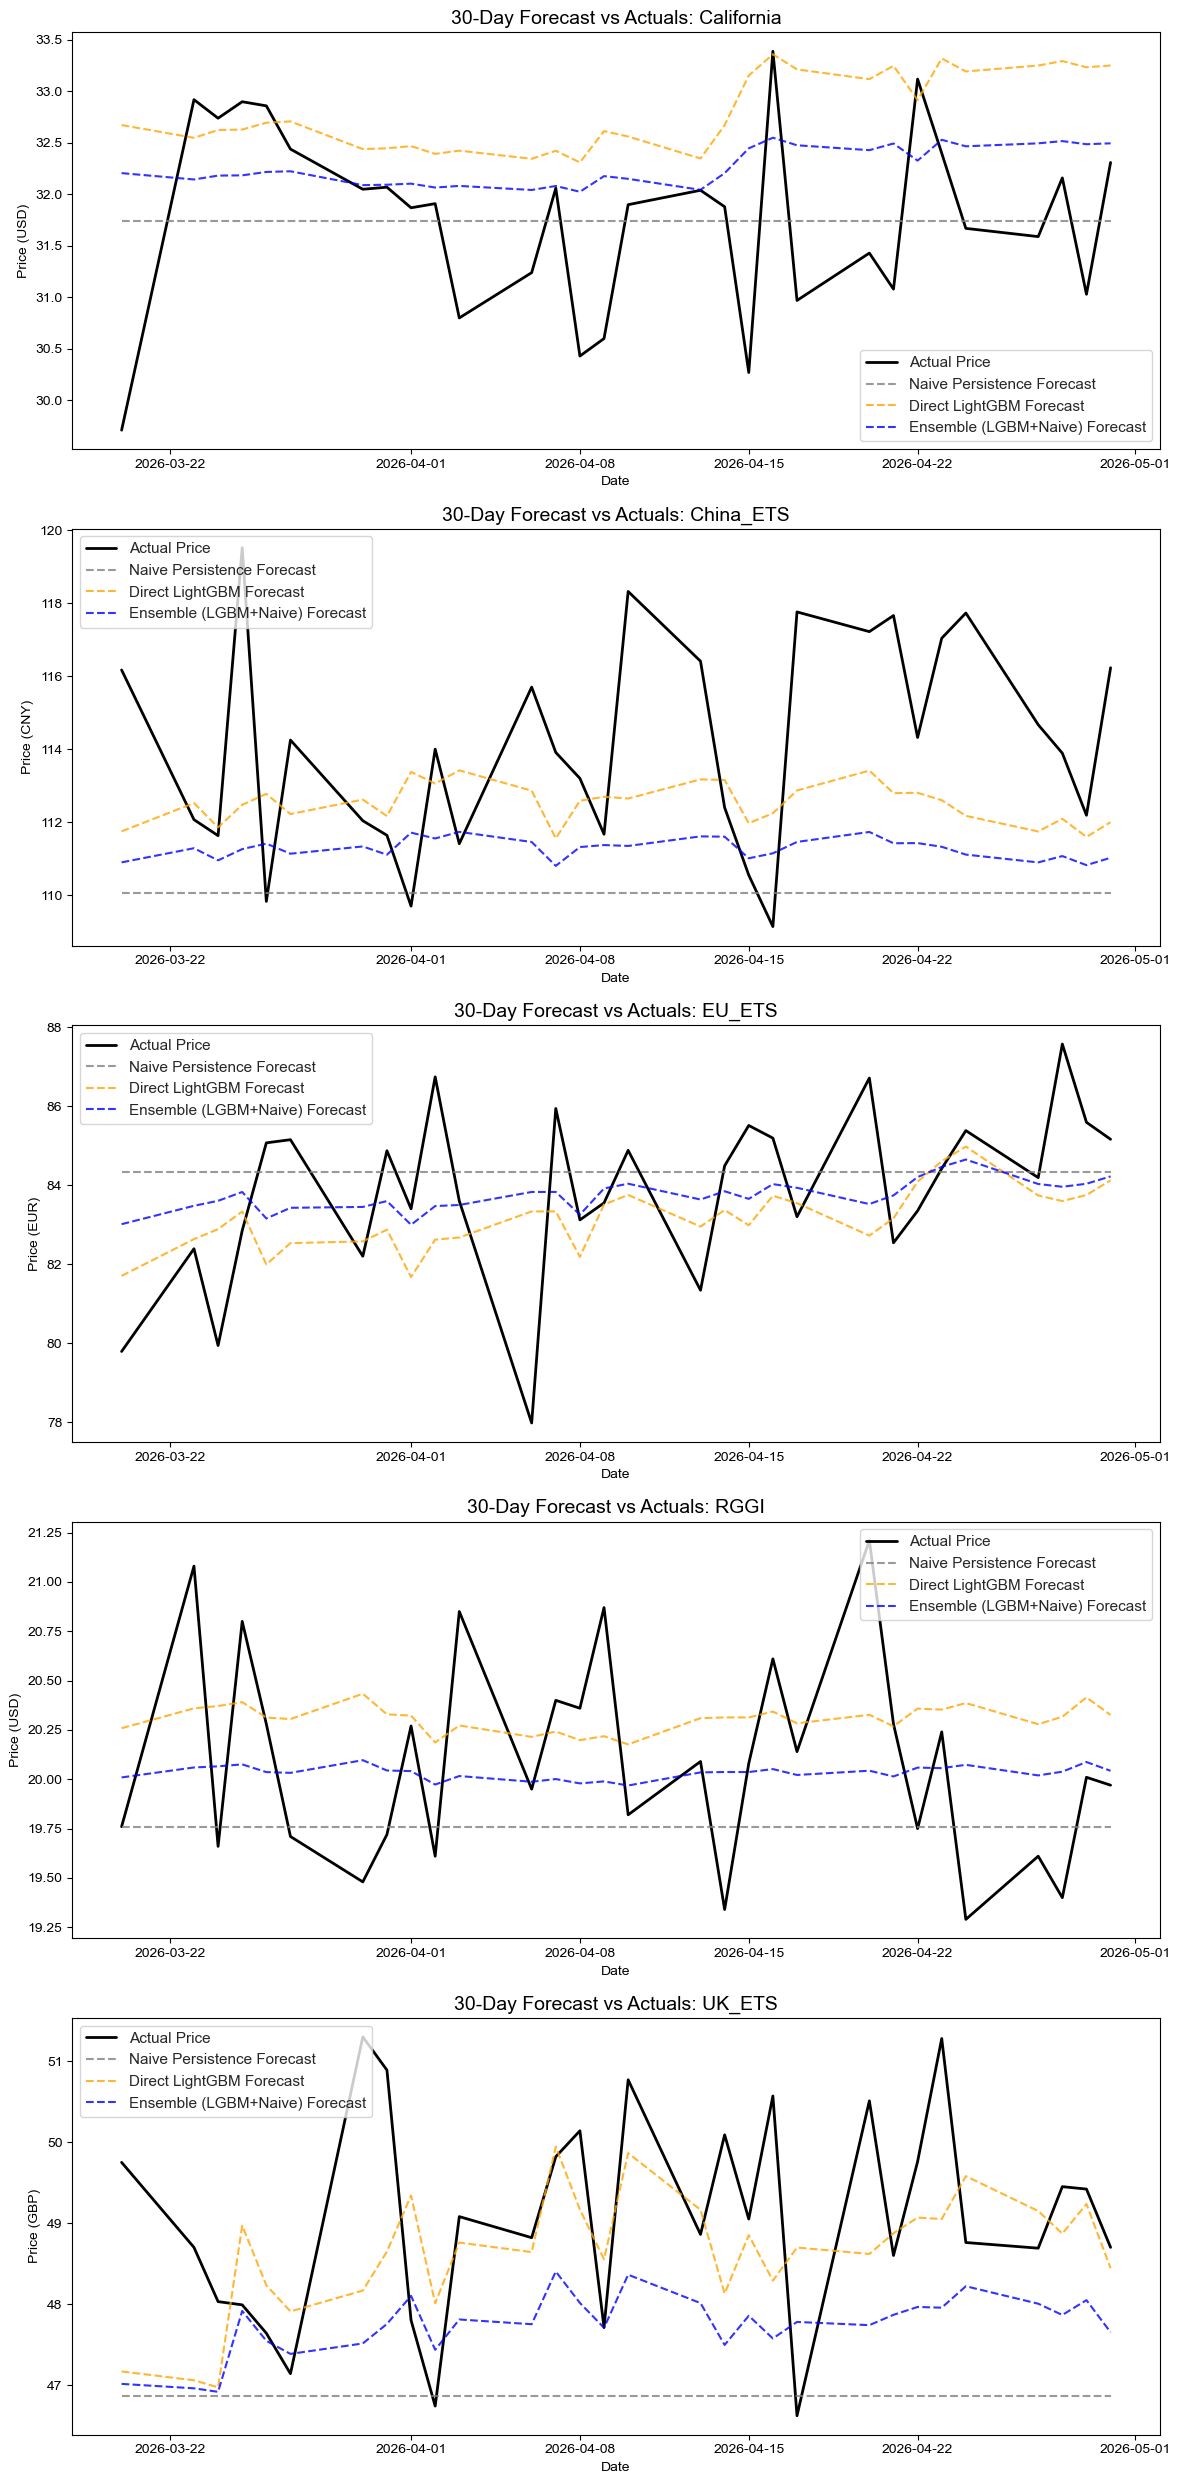

In [8]:
markets = forecasts['market'].unique()
fig, axes = plt.subplots(len(markets), 1, figsize=(12, 5 * len(markets)))
sns.set_theme(style="whitegrid")

models_to_plot = ['Naive Persistence', 'Direct LightGBM', 'Ensemble (LGBM+Naive)']
colors = {'Naive Persistence': 'gray', 'Direct LightGBM': 'orange', 'Ensemble (LGBM+Naive)': 'blue'}

for i, market in enumerate(markets):
    ax = axes[i]
    m_data = forecasts[forecasts['market'] == market]
    
    # Actuals (Ground Truth)
    actuals = m_data[m_data['model_name'] == 'Naive Persistence']
    ax.plot(actuals['date'], actuals['actual_price'], label='Actual Price', color='black', linewidth=2)
    
    # Predictions
    for model in models_to_plot:
        preds = m_data[m_data['model_name'] == model]
        ax.plot(preds['date'], preds['predicted_price'], label=f'{model} Forecast', 
                color=colors[model], linestyle='--', alpha=0.8)
        
    ax.set_title(f"30-Day Forecast vs Actuals: {market}", fontsize=14)
    ax.set_ylabel(f"Price ({actuals['currency'].iloc[0]})")
    ax.set_xlabel("Date")
    ax.legend()
    
plt.tight_layout()
plt.savefig('../../data/outputs/figures/fig_q1_1_price_forecasts.png', bbox_inches='tight')
plt.show()